In [3]:
import numpy as np
from arc import *

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
ns = np.array(range(50, 70, 1))
des = []

for n in ns:
    val = np.sqrt(0.5)*Cesium().getDipoleMatrixElement(6, 0, 0.5, 0.5, n, 1, 1.5, 1.5, +1)
    des.append(val)

des = np.abs(np.array(des))

Text(0.5, 1.0, 'Matrix dipole element between ground and Rydberg states')

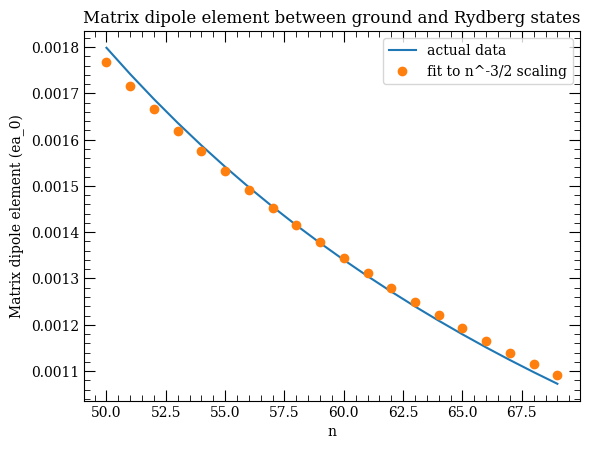

In [6]:
plt.plot(ns, des, label = "actual data")
plt.plot(ns, (0.625)*np.pow(ns.astype(float), -1.5), "o", label = "fit to n^-3/2 scaling")
plt.legend()
plt.ylabel("Matrix dipole element (ea_0)")
plt.xlabel("n")
plt.title("Matrix dipole element between ground and Rydberg states")

Text(0.5, 1.0, 'Comparing two methods of computing Omega')

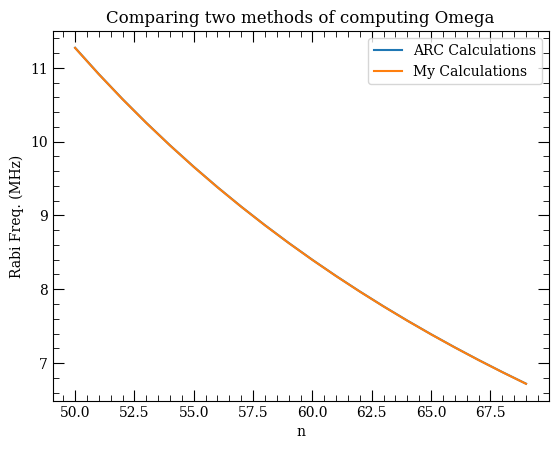

In [7]:
rabi_func = []
rabi_calc = []

for n in ns: # these calcs seem correct!
    val_func = 10**(-6)*Cesium().getRabiFrequency(6, 0, 0.5, 0.5, n, 1, 1.5, +1, 5*10**8, 1)/(2*np.pi)*np.sqrt(0.5)
    rabi_func.append(val_func)

    val_calc = np.abs(Cesium().getDipoleMatrixElement(6, 0, 0.5, 0.5, n, 1, 1.5, 1.5, +1))*35.116 * np.sqrt(5*10**4)*np.sqrt(2/np.pi)*np.sqrt(0.5)
    rabi_calc.append(val_calc)

plt.plot(ns, rabi_func, label = "ARC Calculations")
plt.plot(ns, rabi_calc, label = "My Calculations")

plt.legend()
plt.ylabel("Rabi Freq. (MHz)")
plt.xlabel("n")
plt.title("Comparing two methods of computing Omega")

In [8]:
calculation = PairStateInteractions(Cesium(), 70, 1, 1.5, 70, 1, 1.5, 1.5, 1.5)
c6 = calculation.getC6perturbatively(0,0, 5, 40e9)
print("C_6 = %.0f GHz (mu m)^6" % c6)

for nRange in [3, 5, 7]:
    c6 = calculation.getC6perturbatively(0, 0, nRange, 25e9)
    print(nRange, c6)

for dE in [5e9, 10e9, 20e9, 40e9, 80e9, 90e9, 20e10]:
    c6 = calculation.getC6perturbatively(0, 0, 5, dE)
    print(f"{dE/1e9:>5.0f} GHz  ->  C6 = {c6:.2f}")

C_6 = 78 GHz (mu m)^6
3 77.83372205893451
5 77.83339800388381
7 77.83341319999042
    5 GHz  ->  C6 = 93.81
   10 GHz  ->  C6 = 61.83
   20 GHz  ->  C6 = 77.83
   40 GHz  ->  C6 = 77.84
   80 GHz  ->  C6 = 77.65
   90 GHz  ->  C6 = 77.64
  200 GHz  ->  C6 = 77.64


In [9]:
calculation = PairStateInteractions(Cesium(), 40, 1, 1.5, 40, 1, 1.5, 1.5, 1.5)
c6 = calculation.getC6perturbatively(0,0, 5, 40e9)
print("C_6 = %.0f GHz (mu m)^6" % c6)

for nRange in [3, 5, 7]:
    c6 = calculation.getC6perturbatively(0, 0, nRange, 25e9)
    print(nRange, c6)

for dE in [5e9, 10e9, 20e9, 40e9, 80e9, 90e9, 20e10]:
    c6 = calculation.getC6perturbatively(0, 0, 5, dE)
    print(f"{dE/1e9:>5.0f} GHz  ->  C6 = {c6:.2f}")

C_6 = 0 GHz (mu m)^6
3 0.04957219531789673
5 0.04957222357586115
7 0.04957218357148642
    5 GHz  ->  C6 = -0.00
   10 GHz  ->  C6 = -0.00
   20 GHz  ->  C6 = 0.00
   40 GHz  ->  C6 = 0.13
   80 GHz  ->  C6 = 0.09
   90 GHz  ->  C6 = 0.11
  200 GHz  ->  C6 = 0.11


In [10]:
ns = np.array(range(50, 70, 1))
c6s = []

for n in ns:
    calculation = PairStateInteractions(Cesium(), n, 1, 1.5, n, 1, 1.5, 1.5, 1.5)
    c6 = calculation.getC6perturbatively(0, 0, 5, 40e9)
    c6s.append(c6)

c6s = np.abs(np.array(c6s))

Text(0.5, 1.0, 'C6 coefficient for Cesium NP3/2')

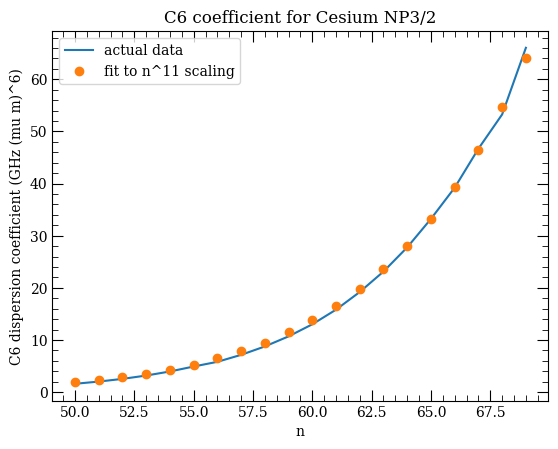

In [11]:
plt.plot(ns, c6s, label = "actual data")
plt.plot(ns, (3.8*10**-19)*np.pow(ns.astype(float), 11), "o", label = "fit to n^11 scaling")
plt.legend()
plt.ylabel("C6 dispersion coefficient (GHz (mu m)^6)")
plt.xlabel("n")
plt.title("C6 coefficient for Cesium NP3/2")

Text(0.5, 1.0, 'Interaction Energy as a function of n')

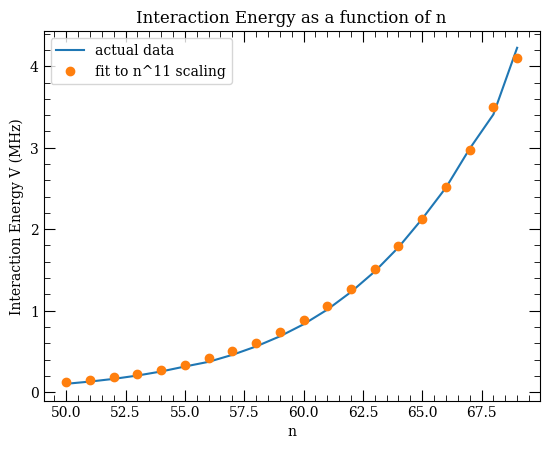

In [12]:
Vs = np.array(c6s)/(5**6) * 1000 # MHz

plt.plot(ns, Vs, label = "actual data")
plt.plot(ns, (3.8*10**-19)*np.pow(ns.astype(float), 11)/(5**6) * 1000, "o", label = "fit to n^11 scaling")
plt.legend()
plt.ylabel("Interaction Energy V (MHz)")
plt.xlabel("n")
plt.title("Interaction Energy as a function of n")

In [13]:
# Things to keep in mind:
# - Get Fidelity
# - Do we want to look at finite temperature effects? for lifetime calculations
# - Do we need degenerate perturbation theory? What are the angles between them?
# - Do we want to be able to change nRange and deltaE of C6 calculations

def getData(nMin = 40, nMax = 70, R = 3.5, I = 5*10**4):
    ns = np.array(range(nMin, nMax + 1, 1))
    l_g = 0
    j_g = 0.5
    mj_g = 0.5
    l_r = 1
    j_r = 1.5
    mj_r = 1.5
    q = +1
    
    rabis = []
    vs = []
    blocks = []
    rads = []
    taus = []
    nrgs = []
    for n in ns:
        de = np.abs(Cesium().getDipoleMatrixElement(6, l_g, j_g, mj_g, n, l_r, j_r, mj_r, q))
        rabi = de * 35.116 * np.sqrt(5*10**4)*np.sqrt(2/np.pi)*np.sqrt(0.5) # MHz
        calculation = PairStateInteractions(Cesium(), n, l_r, j_r, n, l_r, j_r, mj_r, mj_r)
        c6 = calculation.getC6perturbatively(0, 0, 5, 40e9)
        v = c6/(R**6) * 1000 # MHz
        block = np.pow(c6/rabi, 1/6.0) # $\mu m$
        rvdw = calculation.getLeRoyRadius() # $\mu m$
        tau = Cesium().getStateLifetime(n, l_r, j_r) # s
        nrg = Cesium().getEnergy(n, l_r, j_r) # eV

        rabis.append(rabi)
        vs.append(v)
        blocks.append(block)
        rads.append(rvdw)
        taus.append(tau)
        nrgs.append(nrg)

    df = pd.DataFrame()
    df["N"] = ns
    df["Rabi"] = rabis
    df["V"] = vs
    df["Blockade Radius"] = blocks
    df["Van der Waals Radius"] = rads
    df["Lifetime"] = taus
    df["Energy"] = nrgs

    plt.plot(ns, rabis, label = "Rabi Frequency, $\Omega$")
    plt.plot(ns, vs, label = "Interaction Energy, V")
    plt.xlabel("Principle quantum number, n")
    plt.ylabel("Frequency (MHz)")
    plt.title("Rydberg Quantities Scaling with N")
    plt.ylim([0, 200])
    plt.legend()

    return df
    

,N,Rabi,V,Blockade Radius,Van der Waals Radius,Lifetime,Energy
0,40,16.264709,1.998541,0.445938,0.444286,0.000153,-0.010246
1,41,15.610458,2.690436,0.471807,0.469014,0.000166,-0.009706
2,42,14.999091,3.594736,0.498460,0.494411,0.000180,-0.009207
3,43,14.426758,4.764858,0.525828,0.520477,0.000194,-0.008746
4,44,13.890047,6.272902,0.553976,0.547212,0.000209,-0.008319
5,45,13.385918,5.649447,0.547759,0.574617,0.000225,-0.007923
6,46,12.911659,7.090795,0.572333,0.602692,0.000242,-0.007554
7,47,12.464843,9.157806,0.600778,0.631435,0.000259,-0.007210
8,48,12.043290,11.750518,0.629867,0.660848,0.000277,-0.006889
9,49,11.645040,15.107756,0.660501,0.690931,0.000296,-0.006589


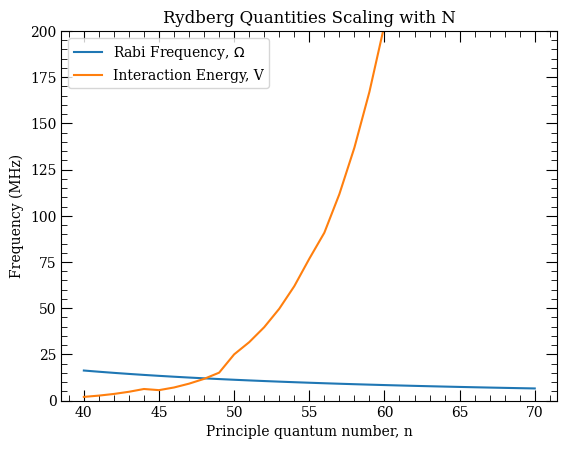

In [14]:
df = getData(R = 2, I = 4*10**4)
df

In [15]:
# 100 milliwatts per 200 microns^2

In [16]:
calc = PairStateInteractions(Cesium(), 60, 1, 1.5, 60, 1, 1.5, 1.5, 1.5, interactionsUpTo=1)
calc.defineBasis(0, 0, 1, 1, 20e9, progressOutput = False, debugOutput = True)
data = calc.basisStates


 ======= Relevant states =======

|59 2D 3/2,59 2D 3/2>	 EnergyDefect = 6.114 GHz
|59 2D 3/2,59 2D 5/2>	 EnergyDefect = 6.447 GHz
|59 2D 5/2,59 2D 3/2>	 EnergyDefect = 6.447 GHz
|59 2D 5/2,59 2D 5/2>	 EnergyDefect = 6.780 GHz
|59 2S 1/2,60 2D 5/2>	 EnergyDefect = -17.913 GHz
|59 2D 5/2,60 2S 1/2>	 EnergyDefect = -14.787 GHz
|59 2S 1/2,61 2D 5/2>	 EnergyDefect = 15.756 GHz
|59 2P 3/2,61 2P 3/2>	 EnergyDefect = -1.946 GHz
|60 2S 1/2,59 2D 5/2>	 EnergyDefect = -14.787 GHz
|60 2D 5/2,59 2S 1/2>	 EnergyDefect = -17.913 GHz
|60 2P 3/2,60 2P 3/2>	 EnergyDefect = 0.000 GHz
|61 2P 3/2,59 2P 3/2>	 EnergyDefect = -1.946 GHz
|61 2D 5/2,59 2S 1/2>	 EnergyDefect = 15.756 GHz
	Matrix dimension	=	 13

 ======= Coupling strengths (radial part only) =======

Calculating coupling (up to  dipole-dipole ) between the pair states
|59 2D 3/2,59 2D 3/2> <---> |60 2P 3/2,60 2P 3/2>
	coupling (C_3/R^3) = 22.05073 /R^ 3  GHz  (mu m)^ 3 

|59 2D 3/2,59 2D 5/2> <---> |60 2P 3/2,60 2P 3/2>
	coupling (C_3/R^3) = 22

In [17]:
rval = 4  # in mum
matrix = calc.matDiagonal
rX = (rval*1.e-6)**3
for matRX in calc.matR:
    matrix = matrix + matRX/rX
    rX *= (rval*1.e-6)

In [18]:
matrix.diagonal()

array([ 6.11433147e+00,  6.44726044e+00,  6.44726045e+00,  6.44726044e+00,
        6.44726045e+00,  6.78018941e+00,  6.78018942e+00,  6.78018943e+00,
       -1.79130656e+01, -1.47869506e+01,  1.57557167e+01, -1.94618487e+00,
       -1.47869506e+01, -1.79130656e+01,  1.00000000e-08, -1.94618487e+00,
        1.57557167e+01])

In [19]:
matrix.toarray()[14, 0]

np.float64(0.027563415479416715)

In [20]:
calc.matDiagonal.diagonal()

array([ 6.11433147e+00,  6.44726044e+00,  6.44726045e+00,  6.44726044e+00,
        6.44726045e+00,  6.78018941e+00,  6.78018942e+00,  6.78018943e+00,
       -1.79130656e+01, -1.47869506e+01,  1.57557167e+01, -1.94618487e+00,
       -1.47869506e+01, -1.79130656e+01,  1.00000000e-08, -1.94618487e+00,
        1.57557167e+01])

In [21]:
i0 = calc.originalPairStateIndex

deltas = calc.matDiagonal.diagonal()
deltas = deltas # GHz
couplings = calc.matR[0][:, i0].toarray() # Units??

n1s = []
l1s = []
j1s = []
mj1s = []
n2s = []
l2s = []
j2s = []
mj2s = []

for i, dat in enumerate(data):
    n1 = dat[0]
    l1 = dat[1]
    j1 = dat[2]
    mj1 = dat[3].item()
    n2 = dat[4]
    l2 = dat[5]
    j2 = dat[6]
    mj2 = dat[7].item()

    n1s.append(n1)
    l1s.append(l1)
    j1s.append(j1)
    mj1s.append(mj1)
    n2s.append(n2)
    l2s.append(l2)
    j2s.append(j2)
    mj2s.append(mj2)
    

In [22]:
R = 4*10**(-6)

df = pd.DataFrame()
df["N1"] = n1s
df["L1"] = l1s
df["J1"] = j1s
df["Mj1"] = mj1s
df["N2"] = n2s
df["L2"] = l2s
df["J2"] = j2s
df["Mj2"] = mj2s

df["$\Delta$"] = deltas # GHz
df["V"] = couplings / R**3

df["V/2$\Delta$"] = df["V"]/(2*df["$\Delta$"])

dfStrong = df[df["V"] > 0.0]
df.head()

,N1,L1,J1,Mj1,N2,L2,J2,Mj2,$\Delta$,V,V/2$\Delta$
0,59,2,1.5,1.5,59,2,1.5,1.5,6.114331,0.027563,0.002254
1,59,2,1.5,1.5,59,2,2.5,1.5,6.447260,-0.055047,-0.004269
2,59,2,1.5,0.5,59,2,2.5,2.5,6.447260,-0.035533,-0.002756
3,59,2,2.5,2.5,59,2,1.5,0.5,6.447260,-0.035533,-0.002756
4,59,2,2.5,1.5,59,2,1.5,1.5,6.447260,-0.055047,-0.004269


In [23]:
calc.diagonalise([2, 4], 4)

In [24]:
df

,N1,L1,J1,Mj1,N2,L2,J2,Mj2,$\Delta$,V,V/2$\Delta$
0,59,2,1.5,1.5,59,2,1.5,1.5,6.114331e+00,0.027563,0.002254
1,59,2,1.5,1.5,59,2,2.5,1.5,6.447260e+00,-0.055047,-0.004269
2,59,2,1.5,0.5,59,2,2.5,2.5,6.447260e+00,-0.035533,-0.002756
3,59,2,2.5,2.5,59,2,1.5,0.5,6.447260e+00,-0.035533,-0.002756
4,59,2,2.5,1.5,59,2,1.5,1.5,6.447260e+00,-0.055047,-0.004269
5,59,2,2.5,2.5,59,2,2.5,0.5,6.780189e+00,0.043456,0.003205
6,59,2,2.5,1.5,59,2,2.5,1.5,6.780189e+00,0.109936,0.008107
7,59,2,2.5,0.5,59,2,2.5,2.5,6.780189e+00,0.043456,0.003205
8,59,0,0.5,0.5,60,2,2.5,2.5,-1.791307e+01,0.001663,-0.000046
9,59,2,2.5,2.5,60,0,0.5,0.5,-1.478695e+01,-0.094144,0.003183


In [25]:
for i in np.arange(9):
    print(Cesium().getEnergyDefect(60, 1, 1.5, n1s[i], l1s[i], j1s[i], n2s[i], l2s[i], j2s[i]) * 1.509*10**24)


6.113560963214267
6.446447982120142
6.446447982120142
6.446447982120142
6.446447982120142
6.779335001025597
6.779335001025597
6.779335001025597
-17.910808317066103


In [26]:
Cesium().getEnergyDefect(60, 1, 1.5, 60, 0, 0.5, 61, 0, 0.5)

1.510176167361152e-25

In [27]:
df.head()

,N1,L1,J1,Mj1,N2,L2,J2,Mj2,$\Delta$,V,V/2$\Delta$
0,59,2,1.5,1.5,59,2,1.5,1.5,6.114331,0.027563,0.002254
1,59,2,1.5,1.5,59,2,2.5,1.5,6.447260,-0.055047,-0.004269
2,59,2,1.5,0.5,59,2,2.5,2.5,6.447260,-0.035533,-0.002756
3,59,2,2.5,2.5,59,2,1.5,0.5,6.447260,-0.035533,-0.002756
4,59,2,2.5,1.5,59,2,1.5,1.5,6.447260,-0.055047,-0.004269


In [28]:
calc.originalPairStateIndex

14

In [31]:
deltas = calc.matDiagonal.diagonal()
deltas = deltas - deltas[10] # GHz